In [36]:
from sklearn.datasets import make_regression

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

In [72]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20,random_state=12)

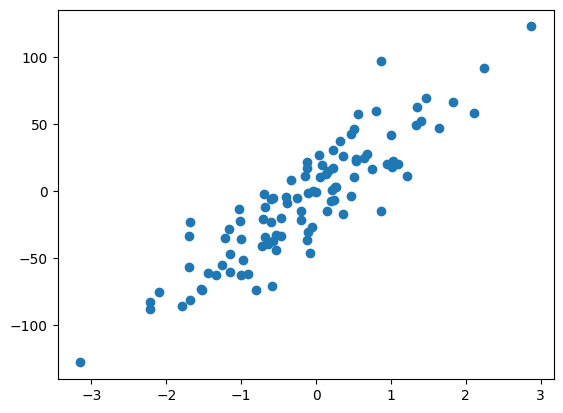

In [38]:
plt.scatter(X,y)

In [39]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X,y)
print(reg.coef_)
print(reg.intercept_)

[38.47185549]
-1.5451093359356598


In [40]:
b = -150
m = 27.82
lr = 0.001

all_b = []
all_cost = []

epochs = 30

for i in range(epochs):
    slope = 0
    cost = 0
    
    for j in range(X.shape[0]):
        slope = slope -2 *(y[j] - (m* X[j]) - b)
        cost = cost +(y[j] - m *X[j] - b) ** 2

    b = b - (lr * slope)
    all_cost.append(cost)
    all_b.append(b)

print(len(all_b))

30


In [41]:
all_b = np.array(all_b).ravel()
all_cost = np.array(all_cost).ravel()
print(all_b.shape)

(30,)


30
[-120.61645039  -97.1096107   -78.30413895  -63.25976155  -51.22425963
  -41.59585809  -33.89313686  -27.73095988  -22.80121829  -18.85742502
  -15.70239041  -13.17836272  -11.15914056   -9.54376284   -8.25146066
   -7.21761892   -6.39054552   -5.72888681   -5.19955984   -4.77609826
   -4.437329     -4.16631359   -3.94950126   -3.7760514    -3.63729151
   -3.52628359   -3.43747726   -3.3664322    -3.30959615   -3.26412731]


C:\Users\KESHAV\Machine-Learning\.venv\Lib\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


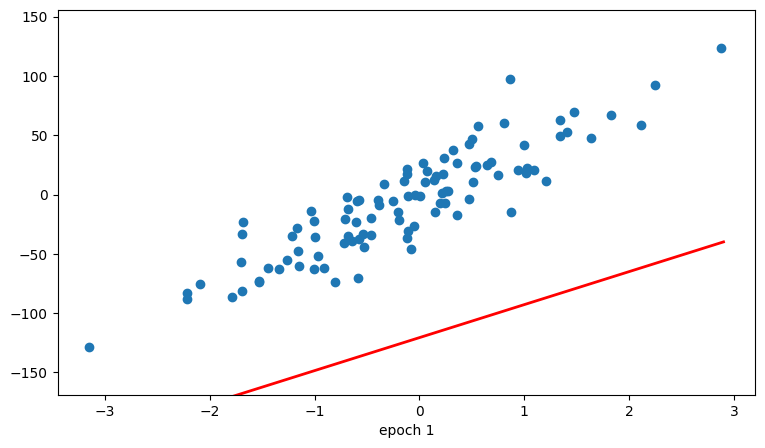

In [42]:
fig, ax = plt.subplots(figsize=(9,5))
# fig.set_tight_laayout(True)

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m -150
ax.scatter(X,y)
line, = ax.plot(x_i,x_i*50 -4, 'r-', linewidth=2)

def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m + all_b[i])
    ax.set_xlabel(label)
    # return line, ax

print(len(all_b))
print(all_b)

anim = FuncAnimation(fig, update, repeat=True, frames=epochs, interval=500)

# f = r"animation.gif"
# writergif = animation.PillowWritter(fps=2)
# anim.save(f, writer=writergif)

In [43]:
print(len(all_b))
print(all_b)

30
[-120.61645039  -97.1096107   -78.30413895  -63.25976155  -51.22425963
  -41.59585809  -33.89313686  -27.73095988  -22.80121829  -18.85742502
  -15.70239041  -13.17836272  -11.15914056   -9.54376284   -8.25146066
   -7.21761892   -6.39054552   -5.72888681   -5.19955984   -4.77609826
   -4.437329     -4.16631359   -3.94950126   -3.7760514    -3.63729151
   -3.52628359   -3.43747726   -3.3664322    -3.30959615   -3.26412731]


In [50]:
print(animation)
print(type(animation))

import matplotlib
import sys
print(matplotlib.__version__)
print(sys.version)

num_epochs = list(range(1, epochs +1))
print(num_epochs)
print(len(all_cost))

<module 'matplotlib.animation' from 'C:\\Users\\KESHAV\\Machine-Learning\\.venv\\Lib\\site-packages\\matplotlib\\animation.py'>
<class 'module'>
3.10.0
3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
30


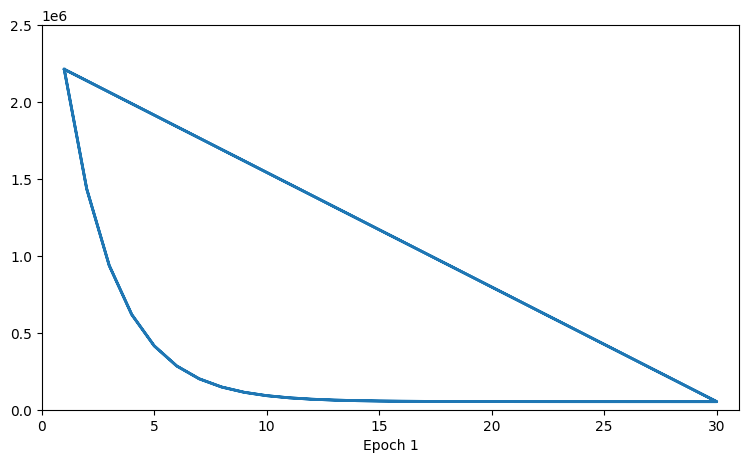

In [51]:
# creating a black window
# for the animation
from IPython.display import HTML

fig = plt.figure(figsize=(9,5))
axis = plt.axes(xlim =(0,31), ylim =(0,2500000))

line, = axis.plot([], [], lw = 2)
xdata, ydata =[], []

# animation function
def animate(i):
    label = f"Epoch {i + 1}"
    xdata.append(num_epochs[i])
    ydata.append(all_cost[i])
    
    line.set_data(xdata, ydata)
    axis.set_xlabel(label)

    return line,

# calling the animation function
anim = FuncAnimation(fig, animate, frames = 30,repeat=False, interval = 500)

f = r"animation.gif"
writergif = animation.PillowWriter(fps=2)
anim.save(f, writer=writergif)
HTML(anim.to_jshtml())

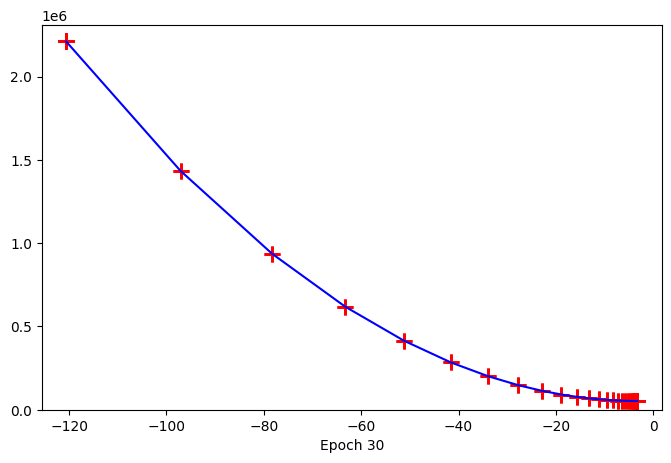

In [66]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(all_b, all_cost, color='blue')

# Empty scatter
sc = ax.scatter([], [],color='red',marker='+', s=120, linewidth=2)

ax.set_xlim(min(all_b)-5, max(all_b)+5)
ax.set_ylim(0, max(all_cost)+100000)

def animate(i):
    x.append(all_b[i])
    y.append(all_cost[i])
    points = np.array(list(zip(x,y)))
    sc.set_offsets(points)
    
    ax.set_xlabel(f"Epoch {i + 1}")

    return sc,
# def animate(i):
#     sc.set_offsets([[all_b[i], all_cost[i]]])
#     ax.set_xlabel(f"Epoch {i+1}")
#     return sc,

ani = animation.FuncAnimation(
    fig, animate,
    frames=len(all_b), interval=500, repeat=True, blit=True)

f = r"animation3.gif"
writergif = animation.PillowWriter(fps=2)
ani.save(f, writer= writergif)

plt.show()

In [65]:
print(hasattr(np, "column_stack"))
print(np.column_stack)

True
<function column_stack at 0x000001DA3E817A60>


In [67]:
b_input = np.linspace(-150,150,100)

In [73]:
cost_input = []

for i in range(len(b_input)):
    this_cost = 0
    for j in range(X.shape[0]):
        this_cost = this_cost + (y[j] - m*X[j] - b_input[i])**2
    # cost-input.append(this_cost)
    print(this_cost)

[2210847.09926344]
[2122724.31348262]
[2036438.0749929]
[1951988.38379426]
[1869375.23988672]
[1788598.64327027]
[1709658.59394492]
[1632555.09191065]
[1557288.13716748]
[1483857.72971541]
[1412263.86955442]
[1342506.55668453]
[1274585.79110573]
[1208501.57281803]
[1144253.90182141]
[1081842.77811589]
[1021268.20170146]
[962530.17257813]
[905628.69074589]
[850563.75620474]
[797335.36895468]
[745943.52899571]
[696388.23632784]
[648669.49095106]
[602787.29286538]
[558741.64207078]
[516532.53856728]
[476159.98235488]
[437623.97343356]
[400924.51180334]
[366061.59746421]
[333035.23041617]
[301845.41065923]
[272492.13819338]
[244975.41301862]
[219295.23513495]
[195451.60454238]
[173444.5212409]
[153273.98523051]
[134939.99651122]
[118442.55508301]
[103781.6609459]
[90957.31409989]
[79969.51454496]
[70818.26228113]
[63503.55730839]
[58025.39962675]
[54383.7892362]
[52578.72613674]
[52610.21032837]
[54478.24181109]
[58182.82058491]
[63723.94664982]
[71101.62000583]
[80315.84065292]
[91366.608

In [71]:
print("len(b_input):", len(b_input))
print("len(X):", len(X))
print("len(y):", len(y))

len(b_input): 100
len(X): 100
len(y): 67
